#Model 5: playBERTlwatt
With
- Asymmetric loss
- Threshold per label
- Label wise attention
- XAI attention output

# 0.0 Dependencies

## 0.1 Installs

In [ ]:
#Install needed package
#For stratification
!pip install iterative-stratification
#For datasets
!pip install -q datasets
#For using trainer
!pip install -U transformers
#For F1 and precision-k usage
!pip install -q torchmetrics
#For nlpaug robustness
!pip install -q nlpaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 147.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 31.0 MB/s eta 0:00:00


## 0.2 Imports

In [ ]:
#Core data
import pandas as pd
import numpy as np

#Sklearn
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score

#Multilabel stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

#Pytorch
import torch
import torch.nn as nn

#Huggingface
from transformers import AutoTokenizer, AutoModel
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
from datasets import Dataset

#Plots
import matplotlib.pyplot as plt

#For evaluation metrics
from torchmetrics.classification import MultilabelF1Score, MultilabelPrecision, MultilabelRecall
from sklearn.metrics import label_ranking_average_precision_score
from torch.utils.data import DataLoader
from IPython.display import display

#Used in robustness
import warnings
import nlpaug.augmenter.char as nac


# 1.0 Dataprep

## 1.1 Load data and relevant columns

In [ ]:
# Load CSV
df = pd.read_csv("tv2_data_cutoffs.csv")

df = df[
    ["Titel", "Genre", "Genre_p", "Form", "Form_p", "Målgruppe", "Målgruppe_p",
     "Emne", "Emne_p", "Stemning", "Stemning_p", "Play description"]]

print(f"Number of rows: {len(df)}")
print(df.head())


Number of rows: 2153
                   Titel                             Genre        Genre_p  \
0  1 døgn, 2 hold, 3 dyr         Dokumentar, Underholdning  Underholdning   
1      1-0 til fremtiden  Livsstil, Dokumentar, Aktualitet     Dokumentar   
2        100 kilo senere                          Livsstil       Livsstil   
3              100% sjov                     Underholdning  Underholdning   
4             12 Monkeys        Drama, Adventure, Thriller      Adventure   

                                Form       Form_p        Målgruppe  \
0  Konkurrence, Iscenesat, Reportage  Konkurrence  Familie, 15+ år   
1                 Portræt, Reportage    Reportage           15+ år   
2                          Iscenesat    Iscenesat           15+ år   
3                  Konkurrence, Show  Konkurrence  Familie, 15+ år   
4                              Serie        Serie           15+ år   

  Målgruppe_p                                               Emne     Emne_p  \
0     Familie  D

## 1.2 Data split (stratification)

In [ ]:
LABEL_COLS = ["Genre", "Form", "Målgruppe", "Emne", "Stemning"]

all_labels = []

for _, row in df.iterrows():
    labels = []

    for col in LABEL_COLS:
        value = row[col]
        if pd.notna(value):
            for label in value.split(","):
                labels.append(label.strip())

    all_labels.append(labels)

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(all_labels)

In [ ]:
#Stratification 70/30 (train and temp)
X = df.index.values

stratsplit = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.30, random_state=4
)
train_idx, temp_idx = next(stratsplit.split(X, Y))

df_train = df.iloc[train_idx]
df_temp  = df.iloc[temp_idx]
Y_temp   = Y[temp_idx]

#Stratification 15/15 (val and test)
stratsplit2 = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.50, random_state=4
)

val_idx, test_idx = next(stratsplit2.split(df_temp.index.values, Y_temp))

df_val  = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

## 1.3 Target encoding (binarization)

In [ ]:
#split label function for binarization
def split_labels(series):
    labels = []

    for value in series.fillna(""):
        parts = []
        for label in value.split(","):
            label = label.strip()
            if label:
                parts.append(label)
        labels.append(parts)

    return labels

#Binarization of all categories
#Genre
mlb_genre = MultiLabelBinarizer()
mlb_genre.fit(split_labels(df["Genre"]))
y_train_genre = mlb_genre.transform(split_labels(df_train["Genre"]))
y_val_genre   = mlb_genre.transform(split_labels(df_val["Genre"]))
y_test_genre  = mlb_genre.transform(split_labels(df_test["Genre"]))

print(f"Genre labels: {len(mlb_genre.classes_)}")

#Form
mlb_form = MultiLabelBinarizer()
mlb_form.fit(split_labels(df["Form"]))
y_train_form = mlb_form.transform(split_labels(df_train["Form"]))
y_val_form   = mlb_form.transform(split_labels(df_val["Form"]))
y_test_form  = mlb_form.transform(split_labels(df_test["Form"]))

print(f"Form labels: {len(mlb_form.classes_)}")

#Målgruppe
mlb_maalgruppe = MultiLabelBinarizer()
mlb_maalgruppe.fit(split_labels(df["Målgruppe"]))
y_train_maalgruppe = mlb_maalgruppe.transform(split_labels(df_train["Målgruppe"]))
y_val_maalgruppe   = mlb_maalgruppe.transform(split_labels(df_val["Målgruppe"]))
y_test_maalgruppe  = mlb_maalgruppe.transform(split_labels(df_test["Målgruppe"]))

print(f"Målgruppe labels: {len(mlb_maalgruppe.classes_)}")

#Emne
mlb_emne = MultiLabelBinarizer()
mlb_emne.fit(split_labels(df["Emne"]))
y_train_emne = mlb_emne.transform(split_labels(df_train["Emne"]))
y_val_emne   = mlb_emne.transform(split_labels(df_val["Emne"]))
y_test_emne  = mlb_emne.transform(split_labels(df_test["Emne"]))

print(f"Emne labels: {len(mlb_emne.classes_)}")

#Stemning
mlb_stemning = MultiLabelBinarizer()
mlb_stemning.fit(split_labels(df["Stemning"]))
y_train_stemning = mlb_stemning.transform(split_labels(df_train["Stemning"]))
y_val_stemning   = mlb_stemning.transform(split_labels(df_val["Stemning"]))
y_test_stemning  = mlb_stemning.transform(split_labels(df_test["Stemning"]))

print(f"Stemning labels: {len(mlb_stemning.classes_)}")


Genre labels: 10
Form labels: 10
Målgruppe labels: 6
Emne labels: 97
Stemning labels: 25


In [ ]:
# Check if stratification worked (70/15/15 distribution)
# Emne category is used as an example
train_counts = y_train_emne.sum(axis=0)
val_counts = y_val_emne.sum(axis=0)
test_counts = y_test_emne.sum(axis=0)
total_counts = train_counts + val_counts + test_counts

# Calculate percentage of total for each split
train_dist = (train_counts / total_counts) * 100
val_dist = (val_counts / total_counts) * 100
test_dist = (test_counts / total_counts) * 100

#check on emne class due to its size
df_check = pd.DataFrame({
    "Label": mlb_emne.classes_,
    "Total Count": total_counts,
    "Train Count": train_counts,
    "Val Count": val_counts,
    "Test Count": test_counts,
    "Train distribution (%)": train_dist,
    "Val distribution (%)": val_dist,
    "Test distribution (%)": test_dist
})

display(df_check.round(1))

,Label,Total Count,Train Count,Val Count,Test Count,Train distribution (%),Val distribution (%),Test distribution (%)
0,Arbejdsliv,196,137,28,31,69.9,14.3,15.8
1,Barndom,39,27,6,6,69.2,15.4,15.4
2,Bedrag,52,36,8,8,69.2,15.4,15.4
3,Beredskab,31,22,4,5,71.0,12.9,16.1
4,Bolig,107,75,16,16,70.1,15.0,15.0
...,...,...,...,...,...,...,...,...
92,Venskab,317,224,46,47,70.7,14.5,14.8
93,Videnskab,37,26,5,6,70.3,13.5,16.2
94,Voksenliv,30,21,4,5,70.0,13.3,16.7
95,Ægteskab,41,29,6,6,70.7,14.6,14.6


## 1.4 Tokenization and dataset creation

In [ ]:
MODEL_NAME = "BSC-LT/MrBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/19.1M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.81M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/741 [00:00<?, ?B/s]

In [ ]:
#Find fitting tokenlength
encodings = tokenizer(
    df_train["Play description"].tolist(),
    add_special_tokens=True,
    truncation=False,
    padding=False
    )

token_lengths = []
for ids in encodings["input_ids"]:
    token_lengths.append(len(ids))

token_lengths = np.array(token_lengths)

print(f"Number of texts: {len(token_lengths)}")
print(f"Median: {np.percentile(token_lengths, 50)}")
print(f"95%: {np.percentile(token_lengths, 95)}")
print(f"99%: {np.percentile(token_lengths, 99)}")
print(f"Max: {token_lengths.max()}")


Number of texts: 1502
Median: 45.0
95%: 79.0
99%: 105.99000000000001
Max: 159


In [ ]:
#then setting the max length
#includes longest text and avoid truncation
MAX_LENGTH = 159

In [ ]:
#Dataset creation
# Tokenize function
def tokenize_fn(examples):
    return tokenizer(
        examples["Play description"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

#prepare dataset
def prepare_dataset(df, y_genre, y_form, y_maalgruppe, y_emne, y_stemning):
    ds = Dataset.from_dict({
        "Play description": df["Play description"].tolist(),
        "y_genre": y_genre.astype(float).tolist(),
        "y_form": y_form.astype(float).tolist(),
        "y_maalgruppe": y_maalgruppe.astype(float).tolist(),
        "y_emne": y_emne.astype(float).tolist(),
        "y_stemning": y_stemning.astype(float).tolist()
        })

    #Apply tokenization
    ds = ds.map(tokenize_fn, batched=True)
    #Set format to torch
    cols_to_keep = ["input_ids", "attention_mask", "y_genre", "y_form", "y_maalgruppe", "y_emne", "y_stemning"]
    ds.set_format(type="torch", columns=cols_to_keep)

    return ds

train_dataset = prepare_dataset(df_train, y_train_genre, y_train_form, y_train_maalgruppe, y_train_emne, y_train_stemning)
val_dataset   = prepare_dataset(df_val, y_val_genre, y_val_form, y_val_maalgruppe, y_val_emne, y_val_stemning)
test_dataset  = prepare_dataset(df_test, y_test_genre, y_test_form, y_test_maalgruppe, y_test_emne, y_test_stemning)


Map:   0%|          | 0/1502 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Map:   0%|          | 0/339 [00:00<?, ? examples/s]

In [ ]:
#makes sure the shape match the labels
sample_dataset = train_dataset[0]

print(f"y_genre shape: {sample_dataset['y_genre'].shape}")
print(f"y_form shape: {sample_dataset['y_form'].shape}")
print(f"y_maalgruppe shape: {sample_dataset['y_maalgruppe'].shape}")
print(f"y_emne shape: {sample_dataset['y_emne'].shape}")
print(f"y_stemning shape: {sample_dataset['y_stemning'].shape}")


y_genre shape: torch.Size([10])
y_form shape: torch.Size([10])
y_maalgruppe shape: torch.Size([6])
y_emne shape: torch.Size([97])
y_stemning shape: torch.Size([25])


# 2.0 Model

## 2.1 Architecture

In [ ]:
#Loss
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8, disable_torch_grad_focal_loss=True):
        super(AsymmetricLoss, self).__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.disable_torch_grad_focal_loss = disable_torch_grad_focal_loss
        self.eps = eps

    def forward(self, x, y):
        """"
        Parameters
        ----------
        x: input logits
        y: targets (multi-label binarized vector)
        """

        # Calculating Probabilities
        x_sigmoid = torch.sigmoid(x)
        xs_pos = x_sigmoid
        xs_neg = 1 - x_sigmoid

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic CE calculation
        los_pos = y * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        # Asymmetric Focusing
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(False)
            pt0 = xs_pos * y
            pt1 = xs_neg * (1 - y)  # pt = p if t > 0 else 1-p
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * y + self.gamma_neg * (1 - y)
            one_sided_w = torch.pow(1 - pt, one_sided_gamma)
            if self.disable_torch_grad_focal_loss:
                torch.set_grad_enabled(True)
            loss *= one_sided_w

        return -loss.sum()

In [ ]:
# label wise attetnion
class LabelAttention(nn.Module):
    def __init__(self, hidden_size, num_labels):
        super().__init__()
        self.num_labels = num_labels
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, num_labels)
        )

    def forward(self, hidden_states, attention_mask):
        #find raw attention scores:
        scores = self.attention(hidden_states).transpose(1, 2)

        #remove padding tokens before applying softmax
        scores = scores.masked_fill(attention_mask.unsqueeze(1) == 0, -10000.0)

        #Convert scores to attention weights
        weights = torch.softmax(scores, dim=-1)

        #Compute the weighted sum of hidden states for each label
        context = torch.bmm(weights, hidden_states)

        return context, weights

In [ ]:
MODEL_NAME = "BSC-LT/MrBERT"

#defining the architecture of the model
class playBERTbase(nn.Module):
    def __init__(self, n_genre, n_form, n_maalgruppe, n_emne, n_stemning):
        super().__init__()

        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        #Freeze backbone
        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size

        # Attention layers for each head
        self.genre_attn = LabelAttention(hidden_size, n_genre)
        self.form_attn = LabelAttention(hidden_size, n_form)
        self.maalgruppe_attn = LabelAttention(hidden_size, n_maalgruppe)
        self.emne_attn = LabelAttention(hidden_size, n_emne)
        self.stemning_attn = LabelAttention(hidden_size, n_stemning)

        #5 heads
        self.genre_head = nn.Linear(hidden_size, 1)
        self.form_head = nn.Linear(hidden_size, 1)
        self.maalgruppe_head = nn.Linear(hidden_size, 1)
        self.emne_head = nn.Linear(hidden_size, 1)
        self.stemning_head = nn.Linear(hidden_size, 1)

        #the loss function
        self.loss_fn = AsymmetricLoss()

    def forward(self, input_ids, attention_mask,
                y_genre=None, y_form=None, y_maalgruppe=None, y_emne=None, y_stemning=None):

        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state

        # Apply label-wise attention instead of just using CLS
        genre_context, genre_weights = self.genre_attn(hidden_states, attention_mask)
        form_context, form_weights = self.form_attn(hidden_states, attention_mask)
        maalgruppe_context, maalgruppe_weights = self.maalgruppe_attn(hidden_states, attention_mask)
        emne_context, emne_weights = self.emne_attn(hidden_states, attention_mask)
        stemning_context, stemning_weights = self.stemning_attn(hidden_states, attention_mask)

        # Get logits and remove the last dimension (squeeze)
        genre_logits = self.genre_head(genre_context).squeeze(-1)
        form_logits = self.form_head(form_context).squeeze(-1)
        maalgruppe_logits = self.maalgruppe_head(maalgruppe_context).squeeze(-1)
        emne_logits = self.emne_head(emne_context).squeeze(-1)
        stemning_logits = self.stemning_head(stemning_context).squeeze(-1)

        logits = {
            "genre": genre_logits,
            "form": form_logits,
            "maalgruppe": maalgruppe_logits,
            "emne": emne_logits,
            "stemning": stemning_logits,
        }

        attention_weights = {
            "genre": genre_weights,
            "form": form_weights,
            "maalgruppe": maalgruppe_weights,
            "emne": emne_weights,
            "stemning": stemning_weights,
        }

        has_labels = True
        for y in [y_genre, y_form, y_maalgruppe, y_emne, y_stemning]:
            if y is None:
                has_labels = False

        if has_labels:
            loss = (
                self.loss_fn(genre_logits, y_genre)
              + self.loss_fn(form_logits, y_form)
              + self.loss_fn(maalgruppe_logits, y_maalgruppe)
              + self.loss_fn(emne_logits, y_emne)
              + self.loss_fn(stemning_logits, y_stemning)
            )
            return loss, logits, attention_weights

        return logits, attention_weights

In [ ]:
#Initialize the model
model = playBERTbase(
    n_genre=len(mlb_genre.classes_),
    n_form=len(mlb_form.classes_),
    n_maalgruppe=len(mlb_maalgruppe.classes_),
    n_emne=len(mlb_emne.classes_),
    n_stemning=len(mlb_stemning.classes_)
)

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: BSC-LT/MrBERT
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 2.2 Training

Epoch,Training Loss,Validation Loss
1,125.262758,111.949883
2,113.586467,113.266754
3,110.837153,109.389946
4,109.260088,109.686073
5,108.823595,106.847572
6,108.016124,111.109901
7,104.805737,110.220200
8,102.815637,104.903694
9,99.745948,104.667648
10,96.056932,107.864059


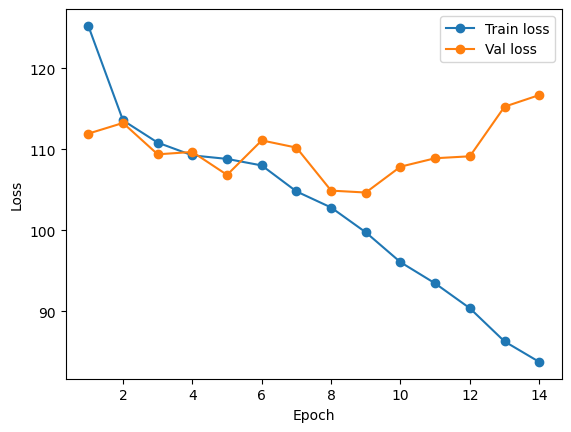

Training done. Model has been set to best iteration: ./checkpoints/checkpoint-846


In [ ]:
#setting the training arguments
training_args = TrainingArguments(
    output_dir="./checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=1e-03,
    optim="adamw_torch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=100,
    report_to="none",
    remove_unused_columns=False,
    bf16=True,
    label_names=["y_genre", "y_form", "y_maalgruppe", "y_emne", "y_stemning"]
)

#the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)
trainer.train()

#creating a loss plot to identify overfit
train_losses = []
train_epochs = []
val_losses = []
val_epochs = []

for entry in trainer.state.log_history:
    if "loss" in entry and "epoch" in entry and "eval_loss" not in entry:
        train_losses.append(entry["loss"])
        train_epochs.append(entry["epoch"])
    if "eval_loss" in entry and "epoch" in entry:
        val_losses.append(entry["eval_loss"])
        val_epochs.append(entry["epoch"])

plt.plot(train_epochs, train_losses, label="Train loss", marker="o")
plt.plot(val_epochs, val_losses, label="Val loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print(f"Training done. Model has been set to best iteration: {trainer.state.best_model_checkpoint}")


# 3.0 Evaluation

## 3.1 Evaluation functions

In [ ]:
#Function to fetch predictions
def predictions(model, dataloader, device, label_counts):
    model.eval()

    all_true = {}
    all_probs = {}
    for head in label_counts.keys():
        all_true[head] = []
        all_probs[head] = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits, attention_weights = model(input_ids=input_ids, attention_mask=attention_mask)

            for head in label_counts.keys():
                all_probs[head].append(torch.sigmoid(logits[head]).cpu())
                all_true[head].append(batch[f"y_{head}"].cpu())

    for head in label_counts.keys():
        all_true[head] = torch.cat(all_true[head], dim=0).long()
        all_probs[head] = torch.cat(all_probs[head], dim=0)

    return all_true, all_probs

#optimal thresholds per label found from validation split
def optimal_thresholds(all_true, all_probs, label_counts):
    optimal_thresholds = {}
    for head, num_classes in label_counts.items():
        y_true = all_true[head].numpy()
        y_prob = all_probs[head].numpy()

        head_thresholds = []

        for label_idx in range(num_classes):
            label_true = y_true[:, label_idx]
            label_prob = y_prob[:, label_idx]

            best_thresh = 0.5
            best_f1 = 0.0

            for i in range(1, 100):
                thresh = i / 100.0
                y_pred = (label_prob >= thresh).astype(int)

                f1 = f1_score(label_true, y_pred, average="binary", zero_division=0)

                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh

            head_thresholds.append(best_thresh)

        optimal_thresholds[head] = torch.tensor(head_thresholds)

    return optimal_thresholds

#Function to calculate F1, Precision, and Recall
def metrics(all_true, all_probs, label_counts, thresholds):
    results = []
    for head, num_classes in label_counts.items():
        th = thresholds[head]

        y_pred = (all_probs[head] >= th).int()

        #F1
        micro_f1_metric = MultilabelF1Score(num_labels=num_classes, average="micro")
        micro_f1 = micro_f1_metric(y_pred, all_true[head]).item()

        macro_f1_metric = MultilabelF1Score(num_labels=num_classes, average="macro")
        macro_f1 = macro_f1_metric(y_pred, all_true[head]).item()

        # Precision
        micro_prec_metric = MultilabelPrecision(num_labels=num_classes, average="micro")
        micro_prec = micro_prec_metric(y_pred, all_true[head]).item()

        macro_prec_metric = MultilabelPrecision(num_labels=num_classes, average="macro")
        macro_prec = macro_prec_metric(y_pred, all_true[head]).item()

        #Recall
        micro_rec_metric = MultilabelRecall(num_labels=num_classes, average="micro")
        micro_rec = micro_rec_metric(y_pred, all_true[head]).item()

        macro_rec_metric = MultilabelRecall(num_labels=num_classes, average="macro")
        macro_rec = macro_rec_metric(y_pred, all_true[head]).item()

        results.append({
            "Category": head.title(),
            "Threshold": "Label-wise",
            "Micro-F1": micro_f1,
            "Macro-F1": macro_f1,
            "Micro-Prec": micro_prec,
            "Macro-Prec": macro_prec,
            "Micro-Rec": micro_rec,
            "Macro-Rec": macro_rec
        })

    return pd.DataFrame(results)

#Function to calculate Label Ranking Average Precision (LRAP)
def lrap(all_true, all_probs, label_counts):
    results = []
    for head in label_counts.keys():
        y_true_np = all_true[head].numpy()
        y_score_np = all_probs[head].numpy()

        lrap = label_ranking_average_precision_score(y_true_np, y_score_np)

        results.append({
            "Category": head.title(),
            "LRAP": lrap
        })
    return pd.DataFrame(results)

#Function to calculate R-Precision
def r_precision(all_true, all_probs, label_counts):
    results = []
    for head in label_counts.keys():
        p_at_k_scores = []
        for i in range(len(all_true[head])):
            true_labels_vector = all_true[head][i]
            probs = all_probs[head][i]
            k = int(true_labels_vector.sum().item())

            if k > 0:
                top_k_indices = torch.topk(probs, k).indices
                correct_in_k = true_labels_vector[top_k_indices].sum().item()
                p_at_k_scores.append(correct_in_k / k)

        if len(p_at_k_scores) > 0:
            avg_p_at_k = np.mean(p_at_k_scores)
        else:
            avg_p_at_k = 0

        results.append({
            "Category": head.title(),
            "R-Precision": avg_p_at_k
        })
    return pd.DataFrame(results)


## 3.2 Evaluation on validation set

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

#dictionary for labels
label_counts = {
    "genre": len(mlb_genre.classes_),
    "form": len(mlb_form.classes_),
    "maalgruppe": len(mlb_maalgruppe.classes_),
    "emne": len(mlb_emne.classes_),
    "stemning": len(mlb_stemning.classes_)
}

# Evaluate on the Validation set
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
val_true, val_probs = predictions(model, val_loader, device, label_counts)

# Calculate optimal thresholds based on validation set
best_thresholds = optimal_thresholds(val_true, val_probs, label_counts)

# Calculate metrics with tuned thresholds
df_val_metrics = metrics(val_true, val_probs, label_counts, thresholds=best_thresholds)
df_val_lrap = lrap(val_true, val_probs, label_counts)
df_val_r_prec = r_precision(val_true, val_probs, label_counts)

# Merge the DataFrames based on the 'Category' column
val_results = pd.merge(df_val_lrap, df_val_r_prec, on="Category")
val_results = pd.merge(val_results, df_val_metrics, on="Category")

display(val_results.round(3))

## 3.3 Evaluation on test set

In [ ]:
# Setup dictionaries and device
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

label_counts = {
    "genre": len(mlb_genre.classes_),
    "form": len(mlb_form.classes_),
    "maalgruppe": len(mlb_maalgruppe.classes_),
    "emne": len(mlb_emne.classes_),
    "stemning": len(mlb_stemning.classes_)
}

# Evaluate on the Test set for final baseline results
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

test_true, test_probs = predictions(model, test_loader, device, label_counts)

# Calculate all metrics with tuned thresholds
df_test_metrics = metrics(test_true, test_probs, label_counts, thresholds=best_thresholds)
df_test_lrap = lrap(test_true, test_probs, label_counts)
df_test_r_prec = r_precision(test_true, test_probs, label_counts)

# Merge and display Test metrics
test_results = pd.merge(df_test_lrap, df_test_r_prec, on="Category")
test_results = pd.merge(test_results, df_test_metrics, on="Category")

display(test_results.round(3))


# 4.0 Output

## 4.1 Output function

In [ ]:
def predict_output(text, model, tokenizer, mlb_dict, thresholds, true_row=None, max_length=MAX_LENGTH):
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    model.to(device)
    model.eval()

    #Tokenize text
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    #Run the text through the model
    with torch.no_grad():
        outputs, attention_weights = model(input_ids=input_ids, attention_mask=attention_mask)

    # Print text
    print("Text:")
    print(text)
    print("\n")

    # Map to find the correct columns if true_row is provided
    col_map = {
        "genre": ("Genre", "Genre_p"),
        "form": ("Form", "Form_p"),
        "maalgruppe": ("Målgruppe", "Målgruppe_p"),
        "emne": ("Emne", "Emne_p"),
        "stemning": ("Stemning", "Stemning_p")
    }

    # Get tokens for attention visualization
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    #Go through all 5 categories
    for head, logits in outputs.items():
        probs = torch.sigmoid(logits)[0]
        classes = mlb_dict[head].classes_

        print(f"Category: {head.title()}")

        all_labels_str = ""

        if true_row is not None:
            col_all, col_p = col_map[head]
            val_all = true_row[col_all]
            val_p = true_row[col_p]
            primary = val_p if pd.notna(val_p) else "None"
            all_labels = val_all if pd.notna(val_all) else "None"
            all_labels_str = str(all_labels)

            print(f"True Primary: {primary}")
            print(f"True All: {all_labels}\n")

        above_results = []
        below_results = []

        #Sort by confidence
        sorted_probs, sorted_class_indices = torch.sort(probs, descending=True)

        # Get the predictions
        for i in range(len(classes)):
            idx = sorted_class_indices[i].item()
            label_name = classes[idx]
            confidence = sorted_probs[i].item()
            thresh = thresholds[head][idx].item()
            is_above = confidence >= thresh

            #Get attention weights for this specific label
            label_weights = attention_weights[head][0][idx]

            # Filter out special tokens and clean text
            valid_words = []

            for j in range(len(tokens)):
                token = tokens[j]
                weight = label_weights[j].item()

                is_special_token = token in tokenizer.all_special_tokens

                if is_special_token == False:
                    clean_token = token.replace('▁', '').replace('Ġ', '').strip()

                    #Check if the token has at least one letter or number
                    has_letter_or_number = False
                    for char in clean_token:
                        if char.isalnum():
                            has_letter_or_number = True

                    if has_letter_or_number == True:
                        valid_words.append([weight, clean_token])

            valid_words.sort()

            # Find the 5 least important words
            least_important_words = []
            for j in range(5):
                if j < len(valid_words):
                    word = valid_words[j][1]
                    least_important_words.append(word)

            #Find the 5 most important words
            most_important_words = []
            for j in range(5):
                if j < len(valid_words):
                    index = -1 - j
                    word = valid_words[index][1]
                    most_important_words.append(word)

            most_important_str = ", ".join(most_important_words)
            least_important_str = ", ".join(least_important_words)

            row_data = {
                "Label": label_name,
                "Confidence": round(confidence, 3),
                "Threshold": round(thresh, 3),
                "Match": ("Yes" if label_name in all_labels_str else "No") if true_row is not None else pd.NA,
                "Top 5 Words": most_important_str,
                "Bottom 5 Words": least_important_str
            }

            if is_above:
                above_results.append(row_data)
            else:
                below_results.append(row_data)

        print("Above threshold (sorted by confidence):")
        if len(above_results) > 0:
            df_above = pd.DataFrame(above_results[:10])
            display(df_above.style.hide(axis='index'))
        else:
            print("No labels above threshold\n")

        print("\nBelow threshold (sorted by confidence):")
        if len(below_results) > 0:
            df_below = pd.DataFrame(below_results[:10])
            display(df_below.style.hide(axis='index'))
        else:
            print("No labels below threshold\n")

        print("\n")

## 4.2 Final output

In [ ]:
# Test on random text string from test set
sample_idx = 5 # Can be changed to any other or a personal string/list of strings
sample_row = df_test.iloc[sample_idx]
sample_text = sample_row["Play description"]

# Map the Binarizers
mlb_dict = {
    "genre": mlb_genre,
    "form": mlb_form,
    "maalgruppe": mlb_maalgruppe,
    "emne": mlb_emne,
    "stemning": mlb_stemning
}

predict_output(sample_text, model, tokenizer, mlb_dict, thresholds=best_thresholds, true_row=sample_row)


Text:
De er de første, der rykker ud, når ulykken sker, og de arbejder ofte under meget vanskelige forhold. Vi følger arbejdet og udfordringerne i landets ambulancer.


Category: Genre
True Primary: Dokumentar
True All: Dokumentar

Above threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Dokumentar,0.601000,0.580000,Yes,"ambul, udfordring, arbejdet, r, arbejder","De, og, de, Vi, vanskelige"
Aktualitet,0.565000,0.490000,No,"erne, landets, arbejder, første, arbejdet","de, De, r, ofte, Vi"
Underholdning,0.541000,0.510000,No,"vanskelige, meget, Vi, ulykken, arbejdet","når, følger, r, ykker, i"
Livsstil,0.537000,0.430000,No,"i, ud, landets, arbejdet, ulykken","forhold, følger, de, når, under"
Reality,0.525000,0.490000,No,"vanskelige, arbejder, sker, De, ulykken","ambul, når, i, r, og"



Below threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Adventure,0.542000,0.630000,No,"ulykken, Vi, første, ancer, landets","og, i, de, ofte, under"
Komedie,0.507000,0.510000,No,"følger, ulykken, når, Vi, ud","og, og, under, meget, i"
Thriller,0.323000,0.570000,No,"De, de, de, arbejder, udfordring","vanskelige, arbejdet, ulykken, i, ofte"
Drama,0.209000,0.600000,No,"De, de, når, de, Vi","erne, landets, vanskelige, arbejdet, ulykken"
Krimi,0.187000,0.660000,No,"De, sker, de, de, og","vanskelige, erne, første, arbejdet, i"




Category: Form
True Primary: Reportage
True All: Dokumentar, Reportage

Above threshold (sorted by confidence):


...

Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Personlig beretning,0.584000,0.640000,No,"ambul, vanskelige, ofte, De, Vi","ykker, følger, er, sker, ud"
Familie,0.558000,0.710000,No,"ancer, når, De, vanskelige, første","arbejdet, er, følger, erne, udfordring"
Venskab,0.545000,0.580000,No,"vanskelige, første, De, de, landets","i, ambul, ulykken, sker, er"
Kultur,0.539000,0.550000,No,"meget, vanskelige, sker, og, landets","De, ulykken, de, Vi, første"
Rejse,0.536000,0.560000,No,"vanskelige, landets, udfordring, De, meget","ud, når, første, arbejdet, der"
Kærlighed,0.532000,0.730000,No,"ud, ancer, følger, under, erne","vanskelige, og, de, De, i"
Indre dæmoner,0.519000,0.550000,No,"ambul, r, udfordring, ancer, ulykken","første, De, Vi, meget, arbejder"
Danmark,0.509000,0.530000,No,"erne, landets, De, forhold, der","når, ofte, følger, ambul, ancer"
Mord,0.507000,0.520000,No,"de, sker, arbejder, vanskelige, de","ancer, under, og, forhold, udfordring"
Mysterie,0.482000,0.510000,No,"de, ykker, r, arbejder, når","landets, erne, i, udfordring, første"




Category: Stemning
True Primary: Intens
True All: Intens, Følelsesladet, Rørende, Oplysende

Above threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Inspirerende,0.627000,0.590000,No,"ambul, og, meget, vanskelige, de","når, følger, sker, arbejder, der"
Feel-good,0.616000,0.010000,No,"de, de, vanskelige, ofte, De","når, arbejder, ancer, sker, følger"
Humoristisk,0.612000,0.440000,No,"og, ambul, r, under, vanskelige","når, ykker, der, Vi, arbejder"
Oplysende,0.609000,0.540000,Yes,"udfordring, ofte, de, erne, der","arbejder, sker, når, følger, forhold"
Følelsesladet,0.608000,0.580000,Yes,"ambul, udfordring, arbejdet, ancer, ulykken","når, sker, Vi, der, meget"
Fascinerende,0.606000,0.010000,No,"meget, og, og, vanskelige, ofte","ancer, når, Vi, arbejder, landets"
Alvorlig,0.589000,0.570000,No,"arbejdet, ykker, ud, ambul, forhold","og, landets, sker, er, der"
Dramatisk,0.587000,0.570000,No,"ambul, når, følger, under, i","vanskelige, meget, erne, udfordring, ofte"
Undersøgende,0.549000,0.540000,No,"forhold, arbejdet, ykker, r, ulykken","landets, sker, der, er, Vi"
Hyggelig,0.511000,0.440000,No,"udfordring, ancer, erne, landets, første","når, forhold, de, sker, ofte"



Below threshold (sorted by confidence):


Label,Confidence,Threshold,Match,Top 5 Words,Bottom 5 Words
Afslappende,0.579000,0.640000,No,"vanskelige, meget, og, udfordring, landets","forhold, følger, ulykken, de, arbejdet"
Intens,0.564000,0.590000,Yes,"følger, når, arbejder, forhold, ykker","vanskelige, de, de, der, og"
Livsbekræftende,0.550000,0.570000,No,"landets, erne, udfordring, ancer, r","når, følger, forhold, arbejder, sker"
Intim,0.547000,0.610000,No,"ambul, ancer, erne, vanskelige, r","følger, når, arbejder, sker, er"
Rørende,0.521000,0.560000,Yes,"ambul, udfordring, ancer, r, erne","følger, når, sker, arbejder, Vi"
Provokerende,0.483000,0.490000,No,"ancer, ykker, arbejder, forhold, arbejdet","og, under, ofte, de, de"
Gribende,0.467000,0.470000,No,"arbejder, udfordring, sker, følger, Vi","under, og, de, og, de"
Dyster,0.362000,0.560000,No,"når, arbejder, følger, ykker, sker","under, erne, der, udfordring, første"
Mystisk,0.334000,0.540000,No,"når, arbejder, følger, forhold, Vi","de, erne, første, og, vanskelige"
Nervepirrende,0.324000,0.490000,No,"når, arbejder, følger, forhold, sker","de, vanskelige, under, erne, landets"


# 5.0 Robustness

## 5.1 Robustness function

In [ ]:
def evaluate_robustness(df_new, dataset_name="New Data"):
    #Transform labels using the already fitted MultiLabelBinarizers
    #ignore warnings from new classes
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        y_genre = mlb_genre.transform(split_labels(df_new["Genre"]))
        y_form = mlb_form.transform(split_labels(df_new["Form"]))
        y_maalgruppe = mlb_maalgruppe.transform(split_labels(df_new["Målgruppe"]))
        y_emne = mlb_emne.transform(split_labels(df_new["Emne"]))
        y_stemning = mlb_stemning.transform(split_labels(df_new["Stemning"]))

    #Prepare dataset and dataloader
    new_dataset = prepare_dataset(df_new, y_genre, y_form, y_maalgruppe, y_emne, y_stemning)
    new_loader = DataLoader(new_dataset, batch_size=16, shuffle=False)

    #Get predictions
    new_true, new_probs = predictions(model, new_loader, device, label_counts)

    #Calculate metrics
    df_new_metrics = metrics(new_true, new_probs, label_counts, thresholds=best_thresholds)
    df_new_lrap = lrap(new_true, new_probs, label_counts)
    df_new_r_prec = r_precision(new_true, new_probs, label_counts)

    # Merge the DataFrames based on the 'Category' column
    new_results = pd.merge(df_new_lrap, df_new_r_prec, on="Category")
    new_results = pd.merge(new_results, df_new_metrics, on="Category")

    print(f"Results for {dataset_name}")
    display(new_results.round(3))
    return new_results

## 5.2 Covariate Shift (Text Length)

In [ ]:
# Copy test set
df_test_shift = df_test.copy()

# Calculate word count using a simple loop
word_counts = []
for text in df_test_shift['Play description']:
    words = str(text).split()
    word_counts.append(len(words))

df_test_shift['word_count'] = word_counts

# Find median length
median_length = df_test_shift['word_count'].median()
print(f"Median word count: {median_length}\n")

# Split dataset into short and long texts
df_short = df_test_shift[df_test_shift['word_count'] < median_length]
df_long = df_test_shift[df_test_shift['word_count'] >= median_length]

# Test covariate shift
short_metrics = evaluate_robustness(df_short, "Short texts (< median)")
long_metrics = evaluate_robustness(df_long, "Long texts (>= median)")

Median word count: 31.0



Map:   0%|          | 0/167 [00:00<?, ? examples/s]

Results for Short Texts (< Median)


,Category,LRAP,R-Precision,Threshold,Micro-F1,Macro-F1,Micro-Prec,Macro-Prec,Micro-Rec,Macro-Rec
0,Genre,0.637,0.462,Label-wise,0.399,0.379,0.265,0.297,0.803,0.697
1,Form,0.594,0.399,Label-wise,0.395,0.282,0.271,0.225,0.728,0.533
2,Maalgruppe,0.953,0.939,Label-wise,0.619,0.374,0.475,0.289,0.890,0.694
3,Emne,0.296,0.240,Label-wise,0.158,0.122,0.097,0.100,0.431,0.296
4,Stemning,0.383,0.296,Label-wise,0.291,0.255,0.183,0.178,0.713,0.621


Map:   0%|          | 0/172 [00:00<?, ? examples/s]

Results for Long Texts (>= Median)


,Category,LRAP,R-Precision,Threshold,Micro-F1,Macro-F1,Micro-Prec,Macro-Prec,Micro-Rec,Macro-Rec
0,Genre,0.595,0.406,Label-wise,0.364,0.306,0.244,0.221,0.716,0.616
1,Form,0.607,0.427,Label-wise,0.416,0.323,0.282,0.232,0.792,0.594
2,Maalgruppe,0.937,0.921,Label-wise,0.669,0.413,0.534,0.333,0.895,0.671
3,Emne,0.310,0.260,Label-wise,0.163,0.160,0.101,0.153,0.419,0.342
4,Stemning,0.411,0.301,Label-wise,0.278,0.232,0.176,0.166,0.661,0.586


## 5.3 Adversarial Robustness (Typos / Noise)

In [ ]:
#aug_word_p: percent words misspelled
# aug_char_p: percent words changed
aug = nac.KeyboardAug(aug_char_p=0.2, aug_word_p=0.25)

sample_text_noisy = df_test.iloc[0]['Play description']
print("Original text:\n", sample_text_noisy)
print("\nmispelled:\n", aug.augment(sample_text_noisy)[0])

Original text:
 I 1920'ernes post-revolutionære Rusland bliver grev Alexander Rostov frataget sine aristokratiske privilegier og sat i husarrest på livstid på Moskvas storslåede Metropol Hotel. Her åbnes hans øjne for Metropols skjulte vidundere, og han må lære, at sand rigdom findes i kærlighed, mod og fællesskab.

mispelled:
 I 1920 ' ernes post - red(lutionærd Rusland blivdg grev Al2xande% Rostov frataget sine arisyomratiwke privilegier og sat i husarrest på livstid på Moskvas s^irslåede Metropol Hotel. Her åbnes uans øjne for Metro0o<s skjulte vidundere, og han må kære, at sand rigdom findes i >ærligh4d, mod og fæl<edskab.


In [ ]:
df_test_noisy = df_test.copy()

#add noise to all texts
noisy_texts = []
for text in df_test_noisy['Play description']:
    noisy_text = aug.augment(str(text))[0]
    noisy_texts.append(noisy_text)

df_test_noisy['Play description'] = noisy_texts
noisy_metrics = evaluate_robustness(df_test_noisy, "Noisy Test Dataset (Typos)")

Map:   0%|          | 0/339 [00:00<?, ? examples/s]

Results for Noisy Test Dataset (Typos)


,Category,LRAP,R-Precision,Threshold,Micro-F1,Macro-F1,Micro-Prec,Macro-Prec,Micro-Rec,Macro-Rec
0,Genre,0.527,0.351,Label-wise,0.273,0.268,0.175,0.192,0.621,0.654
1,Form,0.622,0.481,Label-wise,0.256,0.211,0.154,0.140,0.773,0.727
2,Maalgruppe,0.940,0.920,Label-wise,0.344,0.261,0.208,0.206,0.988,0.969
3,Emne,0.198,0.145,Label-wise,0.095,0.076,0.053,0.060,0.465,0.414
4,Stemning,0.377,0.284,Label-wise,0.246,0.231,0.146,0.148,0.797,0.781


## 5.4 Missing Information (Word Deletion)

In [ ]:
import nlpaug.augmenter.word as naw

# aug_p: percent of words to delete
aug_word = naw.RandomWordAug(action="delete", aug_p=0.15)

sample_text_del = df_test.iloc[0]['Play description']
print("Original text:\n", sample_text_del)
print("\nDeleted words:\n", aug_word.augment(sample_text_del)[0])

Original text:
 I 1920'ernes post-revolutionære Rusland bliver grev Alexander Rostov frataget sine aristokratiske privilegier og sat i husarrest på livstid på Moskvas storslåede Metropol Hotel. Her åbnes hans øjne for Metropols skjulte vidundere, og han må lære, at sand rigdom findes i kærlighed, mod og fællesskab.

Deleted words:
 1920 ' ernes post - revolutionære Rusland bliver grev Alexander sine aristokratiske privilegier og sat i på livstid på storslåede Metropol Hotel. Her åbnes øjne for Metropols skjulte vidundere, og han må lære, sand rigdom findes i kærlighed, mod fællesskab.


In [ ]:
df_test_deleted = df_test.copy()

# remove words from texts
deleted_texts = []
for text in df_test_deleted['Play description']:
    deleted_text = aug_word.augment(str(text))[0]
    deleted_texts.append(deleted_text)

df_test_deleted['Play description'] = deleted_texts

#evaluating on the new dataset
deleted_metrics = evaluate_robustness(df_test_deleted, "Missing Info Dataset (Deleted Words)")

Map:   0%|          | 0/339 [00:00<?, ? examples/s]

Results for Missing Info Dataset (Deleted Words)


,Category,LRAP,R-Precision,Threshold,Micro-F1,Macro-F1,Micro-Prec,Macro-Prec,Micro-Rec,Macro-Rec
0,Genre,0.575,0.408,Label-wise,0.313,0.313,0.202,0.226,0.698,0.709
1,Form,0.657,0.518,Label-wise,0.274,0.242,0.166,0.188,0.787,0.736
2,Maalgruppe,0.931,0.905,Label-wise,0.349,0.267,0.212,0.212,0.993,0.987
3,Emne,0.237,0.177,Label-wise,0.119,0.099,0.067,0.066,0.566,0.457
4,Stemning,0.406,0.316,Label-wise,0.244,0.233,0.145,0.157,0.764,0.764
